# Практическое занятие 6. Кластеризация режимов оборудования

Цель занятия - выполнить обучение без учителя для группировки
режимов оборудования по сенсорным признакам, сравнить k-means,
DBSCAN и Gaussian Mixture, а затем интерпретировать найденные
группы через диагностическую разметку.

Обучение без учителя (unsupervised learning) означает, что модель
не получает целевую переменную во время обучения. Диагностические
метки используются только после кластеризации для проверки
инженерной интерпретации.

**Задача студента.** Нужно выбрать только сенсорные признаки,
выполнить масштабирование, подобрать число кластеров, сравнить
алгоритмы и дать инженерное описание найденных групп. Диагностическую
разметку можно использовать только после обучения, иначе задача
перестает быть кластеризацией.

## Инициализация среды выполнения

Ячейка ниже обеспечивает запуск блокнота в Google Colab и в
локальном Jupyter Notebook. Если проект уже открыт локально,
повторное клонирование не выполняется.

In [1]:
# COLAB_BOOTSTRAP_APPailab
from pathlib import Path
import os
import sys

REQUIRED_PROCESSED_FILES = ['practice_06_equipment_modes_features.csv', 'practice_06_equipment_modes_diagnostics.csv', 'practice_04_06_dataset_catalog.csv', 'practice_04_06_dataset_assignments.csv']
PROJECT_REPOSITORY_URL = "https://github.com/Alexflex/appailab.git"

def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements-colab.txt").exists() and (candidate / "data" / "processed").exists():
            return candidate
    return None

project_root = find_project_root(Path.cwd())

if project_root is None:
    try:
        import google.colab  # type: ignore
        IN_COLAB = True
    except Exception:
        IN_COLAB = False

    if IN_COLAB:
        workdir = Path("/content/appailab")
        if not workdir.exists():
            !git clone -q {PROJECT_REPOSITORY_URL} {workdir}
        project_root = workdir
        os.chdir(project_root)
        !pip install -q -r requirements-colab.txt
    else:
        raise FileNotFoundError(
            "Не найден корень проекта. Откройте блокнот из репозитория appailab "
            "или выполните git clone перед запуском."
        )

sys.path.insert(0, str(project_root / "src"))
missing_files = [
    name for name in REQUIRED_PROCESSED_FILES
    if not (project_root / "data" / "processed" / name).exists()
]
if missing_files:
    raise FileNotFoundError(
        "Не найдены подготовленные CSV: " + ", ".join(missing_files)
        + ". Выполните python scripts/generate_datasets.py."
    )

print(f"Корень проекта: {project_root}")
print("Проверенные CSV:", ", ".join(REQUIRED_PROCESSED_FILES))

Корень проекта: /mnt/f/projects/appai_lab
Проверенные CSV: practice_06_equipment_modes_features.csv, practice_06_equipment_modes_diagnostics.csv, practice_04_06_dataset_catalog.csv, practice_04_06_dataset_assignments.csv


In [2]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

DATA_DIR = project_root / "data" / "processed"
CATALOG_04_06_FILE = DATA_DIR / "practice_04_06_dataset_catalog.csv"
ASSIGNMENTS_04_06_FILE = DATA_DIR / "practice_04_06_dataset_assignments.csv"
RANDOM_STATE = 20260507

## Источники и проверка актуальности

Для занятий 4-6 используются базовые локальные учебные CSV, поэтому
выполнение блокнота не зависит от загрузки внешних архивов. Открытые
источники ниже используются как научно-методические ориентиры для
расширенных заданий и проверки переносимости постановки.

1. NASA C-MAPSS Aircraft Engine Simulator Data - открытый набор
   траекторий деградации авиационных двигателей. Применение:
   временная регрессия, риск утечки между соседними точками,
   кластеризация режимов деградации. URL:
   https://data.nasa.gov/dataset/groups/c-mapss-aircraft-engine-simulator-data
2. Mendeley Data `Partial Discharge Signals in Insulated Power
   Cables with Time-of-Arrival Annotations` - временные сигналы
   частичных разрядов с аннотациями времени прихода импульсов.
   Применение: извлечение PRPD-признаков перед классификацией. URL:
   https://data.mendeley.com/datasets/3mdgxv6zt7
3. UCI `AI4I 2020 Predictive Maintenance Dataset` - промышленно
   мотивированный набор для предиктивного обслуживания. Применение:
   отделение сенсорных признаков от служебных кодов и признаков
   отказов перед кластеризацией. URL:
   https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
4. NASA Prognostics Center of Excellence Data Repository - реестр
   наборов для диагностики и прогнозирования технического состояния.
   Применение: расширение задач кластеризации и анализа временных
   сценариев. URL:
   https://www.nasa.gov/content/prognostics-center-of-excellence-data-set-repository

Проверка ссылок выполнена 2026-05-15. Перед использованием полного
внешнего источника в самостоятельной работе необходимо повторно
проверить карточку набора данных, лицензию, размер архива и формат
файлов.

## Теоретический блок

Кластеризация (clustering) - группировка объектов по сходству.
Метод k-средних (k-means) ищет центры кластеров и минимизирует
сумму квадратов расстояний до ближайшего центра.

DBSCAN (Density-Based Spatial Clustering of Applications with
Noise) - плотностной алгоритм, который выделяет плотные области и
помечает разреженные точки как шум. Gaussian Mixture Model (GMM),
гауссова смесь, описывает данные как смесь нескольких нормальных
распределений.

PCA (Principal Component Analysis), метод главных компонент,
используется для визуализации многомерных данных на плоскости.

## Последовательность работы

Pipeline кластеризации:

1. загрузить feature-CSV без целевой переменной;
2. выбрать только сенсорные признаки;
3. масштабировать признаки;
4. построить PCA-проекцию;
5. подобрать число кластеров;
6. сравнить k-means, DBSCAN и Gaussian Mixture;
7. интерпретировать кластеры через средние профили признаков;
8. только после этого присоединить diagnostics-CSV.

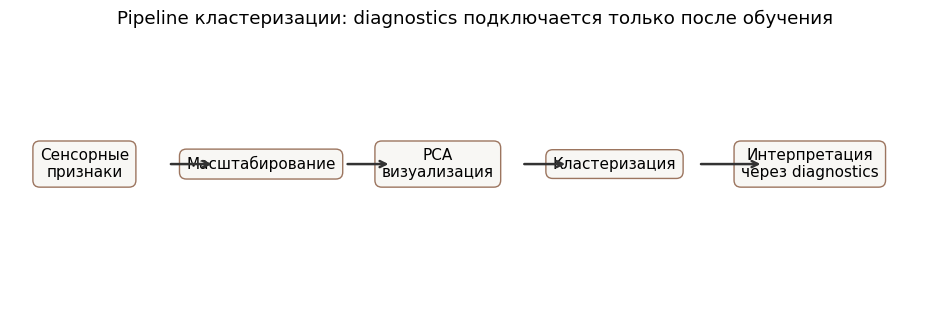

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.axis("off")
steps = [
    ("Сенсорные\nпризнаки", 0.08),
    ("Масштабирование", 0.27),
    ("PCA\nвизуализация", 0.46),
    ("Кластеризация", 0.65),
    ("Интерпретация\nчерез diagnostics", 0.86),
]
for text, x in steps:
    ax.text(
        x,
        0.55,
        text,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="#f8f7f4", edgecolor="#9c755f"),
        transform=ax.transAxes,
    )
for x0, x1 in [(0.17, 0.22), (0.36, 0.41), (0.55, 0.60), (0.74, 0.81)]:
    ax.annotate(
        "",
        xy=(x1, 0.55),
        xytext=(x0, 0.55),
        xycoords=ax.transAxes,
        arrowprops=dict(arrowstyle="->", lw=1.8, color="#333333"),
    )
ax.set_title("Pipeline кластеризации: diagnostics подключается только после обучения")
plt.show()

In [4]:
FEATURES_FILE = DATA_DIR / "practice_06_equipment_modes_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "practice_06_equipment_modes_diagnostics.csv"

df = pd.read_csv(FEATURES_FILE)
diagnostics_df = pd.read_csv(DIAGNOSTICS_FILE)
full_df = df.merge(diagnostics_df, on="sample_id", validate="one_to_one")

display(df.head())
print("Размер feature-таблицы:", df.shape)
print("Размер diagnostics-таблицы:", diagnostics_df.shape)

,sample_id,profile_id,speed_rpm,torque_nm,current_a,voltage_v,temperature_c,vibration_rms_mm_s,acoustic_db,cooling_flow_lpm,efficiency,pressure_kpa
0,1,4,2381.8,6.38916,14.6283,96.534,45.553,2.1899,54.213,15.227,0.88360,97.445
1,2,6,2979.5,8.35411,17.1871,96.564,47.986,1.4968,54.536,18.394,0.90474,102.480
2,3,2,1018.4,3.45685,5.6584,95.034,38.820,1.0653,51.007,17.487,0.87408,100.114
3,4,1,2898.1,6.88526,18.1770,299.752,45.656,1.6331,55.973,16.605,0.83031,95.932
4,5,3,4713.3,13.06525,32.7475,94.128,79.408,2.7742,54.770,14.791,0.80916,99.474


Размер feature-таблицы: (600, 12)
Размер diagnostics-таблицы: (600, 7)


## Структура данных

В feature-CSV нет целевой переменной. Столбцы `true_mode_label`,
`mode_id`, `anomaly_flag` и `health_score` находятся только в
diagnostics-CSV. Их нельзя использовать в обучении кластеризации,
иначе задача обучения без учителя превращается в скрытую
классификацию.

На этом этапе студент должен убедиться, что feature-CSV содержит
только наблюдаемые сенсорные признаки. Скрытая разметка режимов
находится в diagnostics-CSV и будет использована только для
проверки интерпретации кластеров.

,count,mean,std,min,25%,50%,75%,max
sample_id,600.0,300.500000,173.349358,1.00000,150.750000,300.500000,450.250000,600.00000
profile_id,600.0,3.420000,1.702478,1.00000,2.000000,3.000000,5.000000,6.00000
speed_rpm,600.0,3010.245167,1285.702410,965.60000,1945.650000,3087.450000,3937.000000,5768.70000
torque_nm,600.0,8.011381,4.118575,2.08921,3.957030,7.665255,10.217207,19.12878
current_a,600.0,19.451413,11.308352,3.91470,9.111625,17.737450,26.124075,49.95040
voltage_v,600.0,169.862060,113.082059,44.20900,49.695500,96.729500,299.662250,303.30200
temperature_c,600.0,56.244017,21.672511,21.10100,37.944750,51.139000,76.371500,100.46900
vibration_rms_mm_s,600.0,2.520144,1.657091,0.59760,1.342175,2.130100,2.902450,8.64690
acoustic_db,600.0,56.043837,5.805887,45.13900,52.202750,54.890000,58.041000,78.37300
cooling_flow_lpm,600.0,15.097778,3.586843,4.04800,14.412000,16.084000,17.194500,22.13100


Пропуски:


,missing_count
sample_id,0
profile_id,0
speed_rpm,0
torque_nm,0
current_a,0
voltage_v,0
temperature_c,0
vibration_rms_mm_s,0
acoustic_db,0
cooling_flow_lpm,0


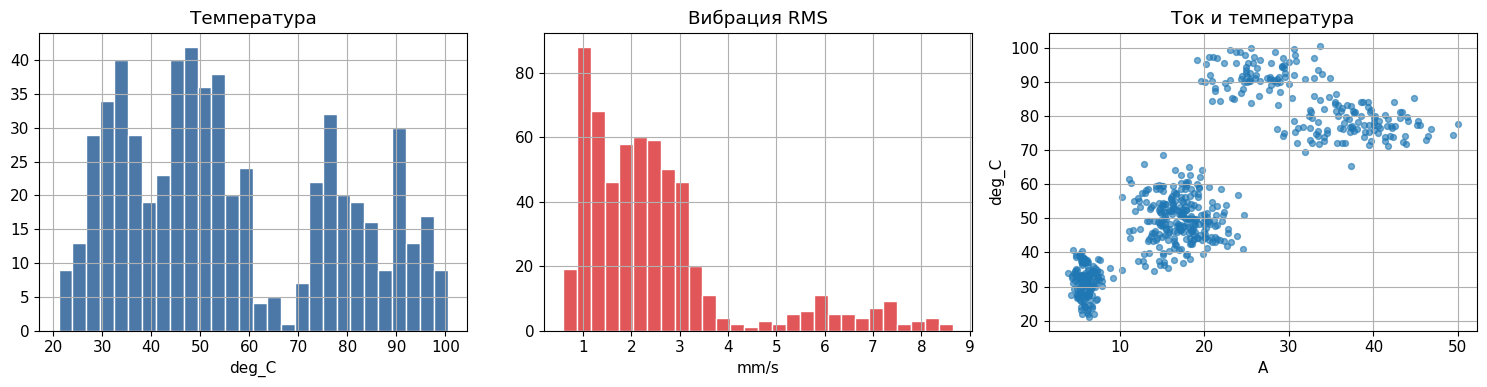

In [5]:
display(df.describe().T)
print("Пропуски:")
display(df.isna().sum().to_frame("missing_count"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["temperature_c"], bins=28, color="#4c78a8", edgecolor="white")
axes[0].set_title("Температура")
axes[0].set_xlabel("deg_C")

axes[1].hist(df["vibration_rms_mm_s"], bins=28, color="#e15759", edgecolor="white")
axes[1].set_title("Вибрация RMS")
axes[1].set_xlabel("mm/s")

axes[2].scatter(df["current_a"], df["temperature_c"], s=18, alpha=0.60)
axes[2].set_title("Ток и температура")
axes[2].set_xlabel("A")
axes[2].set_ylabel("deg_C")
plt.tight_layout()
plt.show()

Корреляционная матрица помогает увидеть группы связанных
признаков. Сильная корреляция не означает причинность, но
показывает, какие величины могут совместно определять расстояния
между объектами при кластеризации.

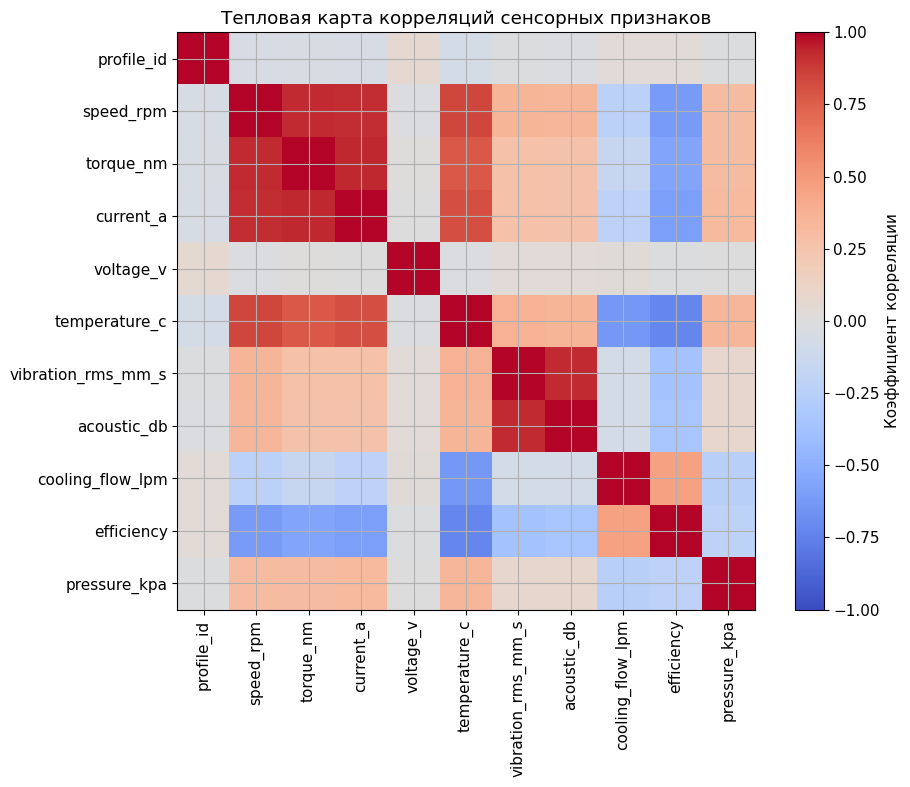

In [6]:
corr = df.select_dtypes(include=[np.number]).drop(columns=["sample_id"]).corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Коэффициент корреляции")
ax.set_title("Тепловая карта корреляций сенсорных признаков")
plt.tight_layout()
plt.show()

## Выбор признаков и масштабирование

In [7]:
cluster_features = ['speed_rpm', 'torque_nm', 'current_a', 'voltage_v', 'temperature_c', 'vibration_rms_mm_s', 'acoustic_db', 'cooling_flow_lpm', 'efficiency', 'pressure_kpa']

forbidden_columns = {"true_mode_label", "mode_id", "anomaly_flag", "health_score", "maintenance_priority"}
leaked = forbidden_columns.intersection(cluster_features)
if leaked:
    raise ValueError(f"Обнаружена утечка диагностической разметки: {sorted(leaked)}")

X = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Масштабированная матрица признаков:", X_scaled.shape)

Масштабированная матрица признаков: (600, 10)


In [8]:
diagnostics_usage_explanation = 'Diagnostics-CSV нельзя использовать до кластеризации, потому что он содержит скрытую разметку режимов и показатели состояния; их включение превратит обучение без учителя в скрытую классификацию.'
print(diagnostics_usage_explanation)

Diagnostics-CSV нельзя использовать до кластеризации, потому что он содержит скрытую разметку режимов и показатели состояния; их включение превратит обучение без учителя в скрытую классификацию.


## PCA-визуализация

Доля объясненной дисперсии PC1 и PC2: [0.4762 0.1627]


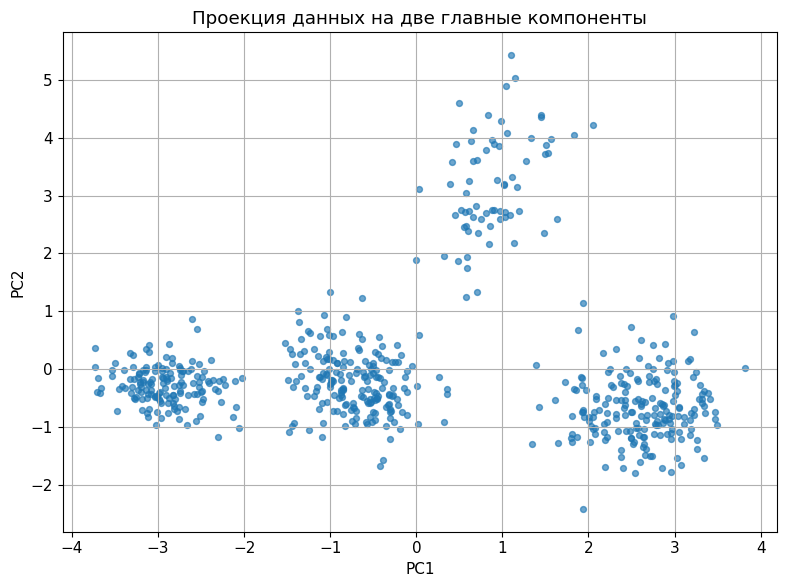

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
explained = pca.explained_variance_ratio_
print("Доля объясненной дисперсии PC1 и PC2:", np.round(explained, 4))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pca_df["PC1"], pca_df["PC2"], s=18, alpha=0.65)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Проекция данных на две главные компоненты")
plt.tight_layout()
plt.show()

## PCA biplot

Biplot - совместная визуализация объектов и направлений признаков
в координатах главных компонент. Стрелки показывают, какие
признаки сильнее связаны с направлениями PC1 и PC2. Это
объяснительная схема, а не строгая физическая модель.

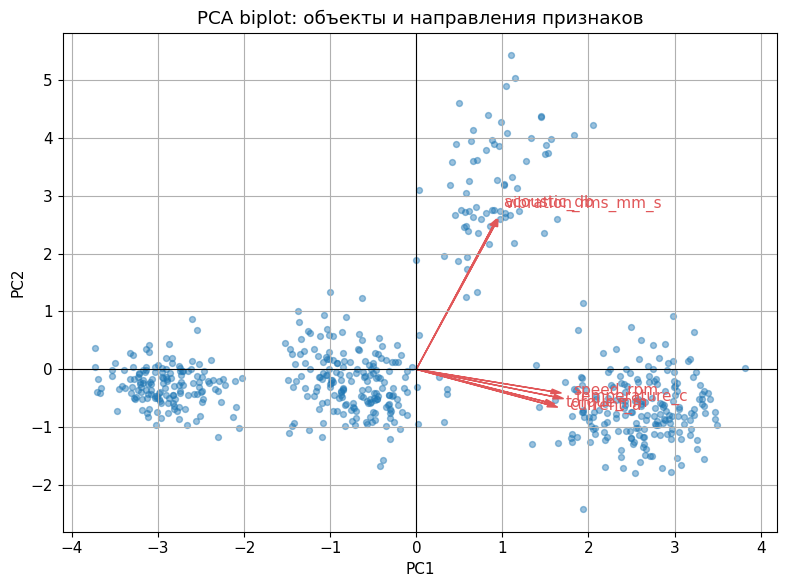

,PC1_loading,PC2_loading,length
acoustic_db,0.233209,0.648942,0.689574
vibration_rms_mm_s,0.237020,0.647467,0.689487
temperature_c,0.427792,-0.126713,0.446164
current_a,0.410798,-0.163701,0.442214
speed_rpm,0.421480,-0.102491,0.433763
torque_nm,0.402378,-0.150273,0.429523


In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=cluster_features,
)
top_loading_features = (
    loadings.assign(length=lambda data: np.sqrt(data["PC1_loading"] ** 2 + data["PC2_loading"] ** 2))
    .sort_values("length", ascending=False)
    .head(6)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pca_df["PC1"], pca_df["PC2"], s=18, alpha=0.45)
scale = 4.0
for feature, row in top_loading_features.iterrows():
    ax.arrow(
        0,
        0,
        row["PC1_loading"] * scale,
        row["PC2_loading"] * scale,
        color="#e15759",
        head_width=0.08,
        length_includes_head=True,
    )
    ax.text(row["PC1_loading"] * scale * 1.08, row["PC2_loading"] * scale * 1.08, feature, color="#e15759")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA biplot: объекты и направления признаков")
plt.tight_layout()
plt.show()
display(top_loading_features)

## Выбор числа кластеров для k-means

,k,inertia,silhouette
0,2,3732.667463,0.355319
1,3,2816.733731,0.406446
2,4,2327.151861,0.407593
3,5,1857.064224,0.344582
4,6,1677.886423,0.329702
5,7,1526.242940,0.346640


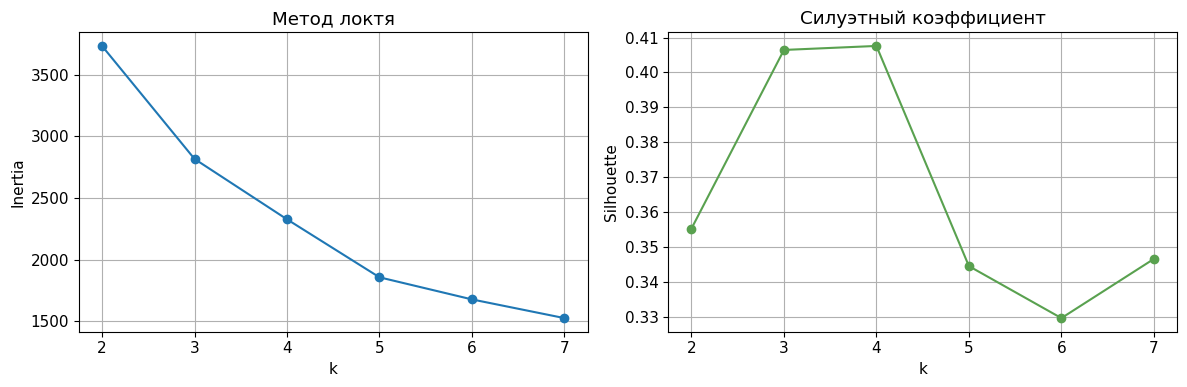

In [11]:
k_rows = []
for k in range(2, 8):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    k_rows.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
        }
    )
k_metrics_df = pd.DataFrame(k_rows)
display(k_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_metrics_df["k"], k_metrics_df["inertia"], marker="o")
axes[0].set_title("Метод локтя")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_metrics_df["k"], k_metrics_df["silhouette"], marker="o", color="#59a14f")
axes[1].set_title("Силуэтный коэффициент")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

## Обучение k-means, DBSCAN и Gaussian Mixture

In [12]:
n_clusters = 5
dbscan_eps = 0.95

kmeans = KMeans(n_clusters=n_clusters, n_init=30, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=dbscan_eps, min_samples=8)
dbscan_labels = dbscan.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=n_clusters, covariance_type="full", random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_scaled)

def safe_silhouette(labels: np.ndarray) -> float:
    unique = set(labels)
    if len(unique) <= 1 or len(unique) >= len(labels):
        return float("nan")
    return silhouette_score(X_scaled, labels)

clustering_metrics = pd.DataFrame(
    [
        {"method": "kmeans", "clusters": len(set(kmeans_labels)), "silhouette": safe_silhouette(kmeans_labels)},
        {"method": "dbscan", "clusters": len(set(dbscan_labels)) - int(-1 in set(dbscan_labels)), "silhouette": safe_silhouette(dbscan_labels)},
        {"method": "gaussian_mixture", "clusters": len(set(gmm_labels)), "silhouette": safe_silhouette(gmm_labels)},
    ]
)
display(clustering_metrics)

,method,clusters,silhouette
0,kmeans,5,0.344582
1,dbscan,6,-0.051283
2,gaussian_mixture,5,0.343724


In [13]:
cluster_number_explanation = 'Рациональное число кластеров выбирается не только по максимуму силуэтного коэффициента, но и по инженерной интерпретируемости профилей режимов.'
print(cluster_number_explanation)

Рациональное число кластеров выбирается не только по максимуму силуэтного коэффициента, но и по инженерной интерпретируемости профилей режимов.


DBSCAN может присвоить части наблюдений метку `-1`. Это не номер
кластера, а обозначение шума: точки недостаточно плотно связаны с
соседями при выбранном `eps`.

In [14]:
dbscan_noise_count = int((dbscan_labels == -1).sum())
dbscan_summary = pd.Series(dbscan_labels).value_counts().sort_index().to_frame("count")
display(dbscan_summary)
print("Число точек DBSCAN с меткой -1 (шум):", dbscan_noise_count)

,count
-1,408
0,76
1,48
2,47
3,13
4,6
5,2


Число точек DBSCAN с меткой -1 (шум): 408


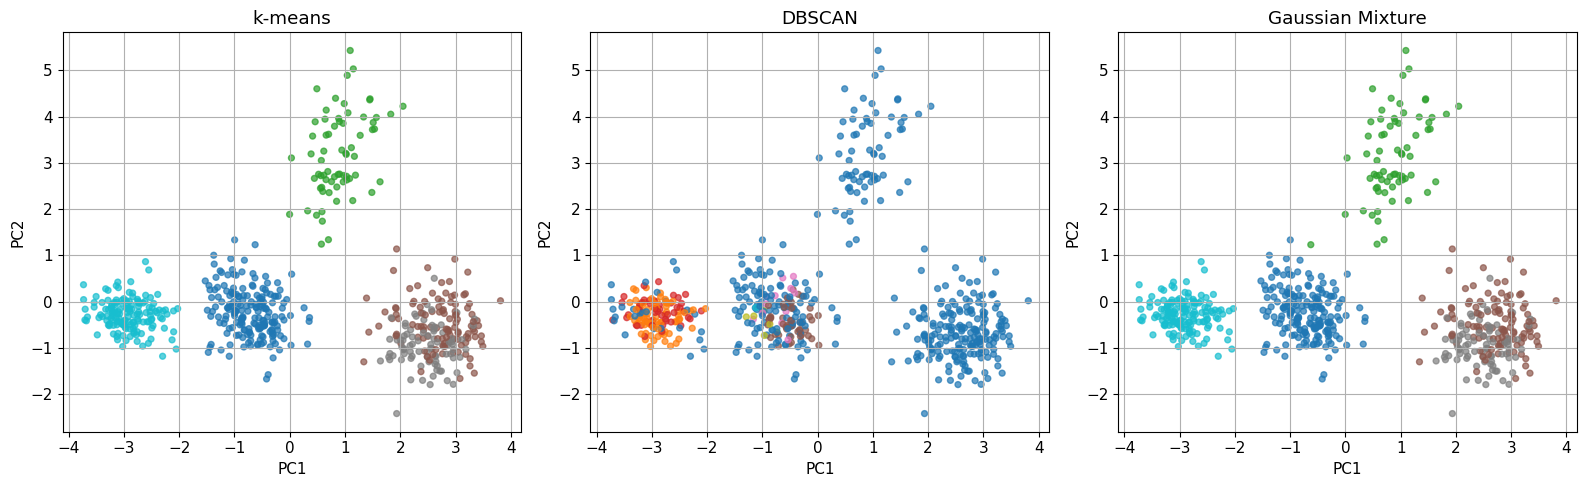

In [15]:
cluster_plot_df = pca_df.copy()
cluster_plot_df["kmeans_cluster"] = kmeans_labels
cluster_plot_df["dbscan_cluster"] = dbscan_labels
cluster_plot_df["gmm_cluster"] = gmm_labels

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, column, title in zip(
    axes,
    ["kmeans_cluster", "dbscan_cluster", "gmm_cluster"],
    ["k-means", "DBSCAN", "Gaussian Mixture"],
):
    scatter = ax.scatter(cluster_plot_df["PC1"], cluster_plot_df["PC2"], c=cluster_plot_df[column], cmap="tab10", s=18, alpha=0.70)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

## Интерпретация кластеров

In [16]:
interpreted_df = full_df.copy()
interpreted_df["kmeans_cluster"] = kmeans_labels

cluster_profile = interpreted_df.groupby("kmeans_cluster")[cluster_features].mean().round(3)
display(cluster_profile)

diagnostic_crosstab = pd.crosstab(
    interpreted_df["kmeans_cluster"],
    interpreted_df["true_mode_label"],
    normalize="index",
).round(3)
display(diagnostic_crosstab)

print("Adjusted Rand Index с диагностической разметкой:",
      round(adjusted_rand_score(interpreted_df["true_mode_label"], kmeans_labels), 4))

,speed_rpm,torque_nm,current_a,voltage_v,temperature_c,vibration_rms_mm_s,acoustic_db,cooling_flow_lpm,efficiency,pressure_kpa
kmeans_cluster,,,,,,,,,,
0,3015.989,7.577,17.421,171.505,47.049,1.914,54.074,16.815,0.880,99.749
1,2914.371,6.822,16.048,187.283,56.855,6.539,68.966,15.828,0.855,99.853
2,4812.495,14.843,38.061,169.871,77.560,2.936,57.590,16.290,0.842,100.723
3,3947.265,9.920,26.359,158.162,92.254,2.623,56.431,7.265,0.820,100.989
4,1193.921,3.000,5.965,166.541,31.392,1.091,51.288,16.190,0.899,99.246


true_mode_label,cooling_degraded,high_load,idle,nominal,sensor_drift,vibration_alarm
kmeans_cluster,,,,,,
0,0.0,0.0,0.0,0.802,0.187,0.011
1,0.0,0.0,0.0,0.000,0.000,1.000
2,0.0,1.0,0.0,0.000,0.000,0.000
3,1.0,0.0,0.0,0.000,0.000,0.000
4,0.0,0.0,1.0,0.000,0.000,0.000


Adjusted Rand Index с диагностической разметкой: 0.9035


## Профили кластеров

Для инженерной интерпретации удобно рассматривать не только
расположение точек на PCA-графике, но и средние нормированные
значения признаков внутри каждого кластера. Такой профиль
помогает назвать кластер: например, "высокая нагрузка",
"повышенная вибрация" или "ухудшенное охлаждение".

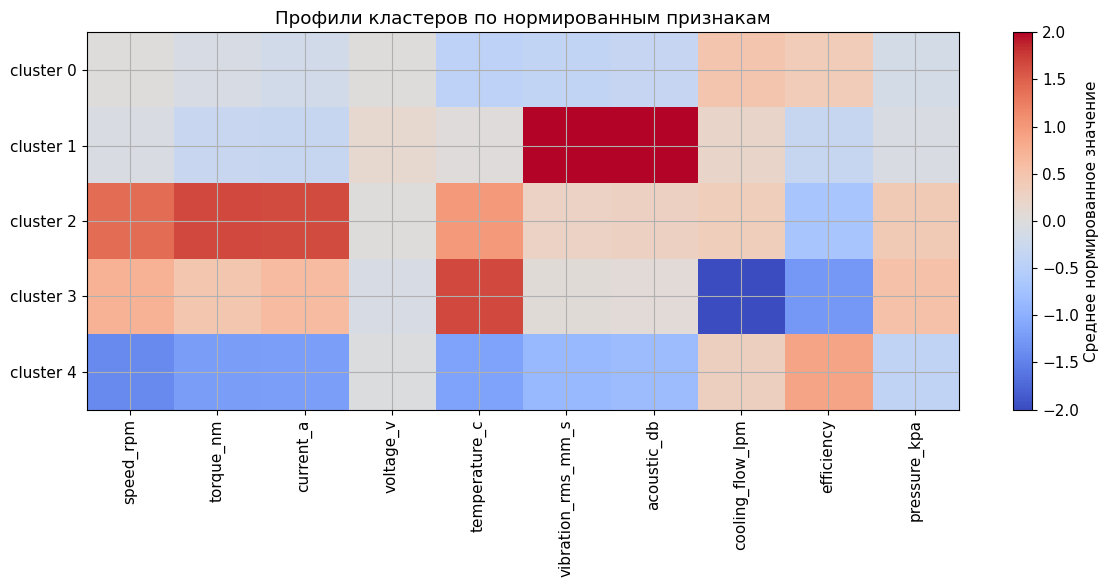

,speed_rpm,torque_nm,current_a,voltage_v,temperature_c,vibration_rms_mm_s,acoustic_db,cooling_flow_lpm,efficiency,pressure_kpa
kmeans_cluster,,,,,,,,,,
0,0.004,-0.106,-0.180,0.015,-0.425,-0.366,-0.340,0.479,0.375,-0.129
1,-0.075,-0.289,-0.301,0.154,0.028,2.427,2.228,0.204,-0.323,-0.073
2,1.403,1.660,1.647,0.000,0.984,0.251,0.267,0.333,-0.676,0.394
3,0.729,0.464,0.611,-0.104,1.663,0.062,0.067,-2.186,-1.263,0.536
4,-1.414,-1.218,-1.194,-0.029,-1.148,-0.863,-0.820,0.305,0.890,-0.399


In [17]:
scaled_feature_df = pd.DataFrame(X_scaled, columns=cluster_features, index=df.index)
scaled_feature_df["kmeans_cluster"] = kmeans_labels
cluster_profile_scaled = scaled_feature_df.groupby("kmeans_cluster")[cluster_features].mean()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(cluster_profile_scaled, cmap="coolwarm", aspect="auto", vmin=-2.0, vmax=2.0)
ax.set_xticks(range(len(cluster_features)))
ax.set_xticklabels(cluster_features, rotation=90)
ax.set_yticks(range(len(cluster_profile_scaled.index)))
ax.set_yticklabels([f"cluster {i}" for i in cluster_profile_scaled.index])
fig.colorbar(im, ax=ax, label="Среднее нормированное значение")
ax.set_title("Профили кластеров по нормированным признакам")
plt.tight_layout()
plt.show()
display(cluster_profile_scaled.round(3))

In [18]:
cluster_profile_interpretation = 'Например, кластер с высокой температурой и низким расходом охлаждения можно интерпретировать как режим ухудшенного охлаждения; кластер с высокой вибрацией - как режим вибрационной тревоги.'
print(cluster_profile_interpretation)

Например, кластер с высокой температурой и низким расходом охлаждения можно интерпретировать как режим ухудшенного охлаждения; кластер с высокой вибрацией - как режим вибрационной тревоги.


## Антипример: скрытая классификация вместо кластеризации

> **Внимание. АНТИПРИМЕР - НЕ ИСПОЛЬЗОВАТЬ КАК РАБОЧИЙ ПОДХОД.**
> Если добавить в признаки `mode_id`, `anomaly_flag` или
> `health_score`, алгоритм получает диагностическую разметку и
> перестает решать задачу обучения без учителя. Такой результат
> нельзя считать кластеризацией сенсорных режимов.

In [19]:
leakage_features = cluster_features + ["mode_id", "anomaly_flag"]
leakage_df = full_df[leakage_features]
leakage_scaled = StandardScaler().fit_transform(leakage_df)
leakage_labels = KMeans(n_clusters=n_clusters, n_init=30, random_state=RANDOM_STATE).fit_predict(leakage_scaled)
print("ARI строгой кластеризации:",
      round(adjusted_rand_score(full_df["true_mode_label"], kmeans_labels), 4))
print("ARI антипримера с диагностической разметкой:",
      round(adjusted_rand_score(full_df["true_mode_label"], leakage_labels), 4))

ARI строгой кластеризации: 0.9035
ARI антипримера с диагностической разметкой: 0.9576


## Реестр найденных наборов данных и развернутые задания

В этом разделе используется единый реестр открытых источников для
занятий 4-6. Реестр не загружает крупные архивы автоматически.
Его назначение - показать, как переносить базовую учебную
постановку на реальные или открытые исследовательские источники.

Для занятия 6 студент должен выбрать один источник
из таблицы ниже и описать, как на нем можно воспроизвести логику
базового блокнота: определить признаки, целевую переменную или
скрытую разметку, способ разбиения выборки, риск утечки данных и
ожидаемые визуализации.

In [20]:
dataset_catalog_04_06 = pd.read_csv(CATALOG_04_06_FILE)
dataset_assignments_04_06 = pd.read_csv(ASSIGNMENTS_04_06_FILE)

pd.set_option("display.max_colwidth", 120)
display(
    dataset_catalog_04_06[
        [
            "dataset_id",
            "name",
            "object",
            "lessons",
            "access",
            "risk_level",
            "implementation_status",
            "checked_at",
        ]
    ]
)

,dataset_id,name,object,lessons,access,risk_level,implementation_status,checked_at
0,nasa_cmapss,C-MAPSS Aircraft Engine Simulator Data,симулированные траектории деградации авиационного турбовентиляторного двигателя,"4,6",NASA Open Data Portal,средний,methodology_only,2026-05-15
1,mendeley_pd_cables_toa,Partial Discharge Signals in Insulated Power Cables with Time-of-Arrival Annotations,временные сигналы частичных разрядов в силовых кабелях,5,Mendeley Data,средний,methodology_only,2026-05-15
2,zenodo_pd_calibrator,Dataset for New Synthetic Partial Discharge Calibrator,сигналы калибратора частичных разрядов,5,Zenodo,низкий,methodology_only,2026-05-15
3,uci_ai4i_2020,AI4I 2020 Predictive Maintenance Dataset,"синтетические, но промышленно мотивированные режимы оборудования и отказы",6,UCI Machine Learning Repository,средний,methodology_only,2026-05-15
4,nasa_pcoe_adapt,NASA PCoE ADAPT Diagnostic Data,диагностические данные испытательного стенда электропитания ADAPT,6,NASA Prognostics Center of Excellence,высокий,methodology_only,2026-05-15


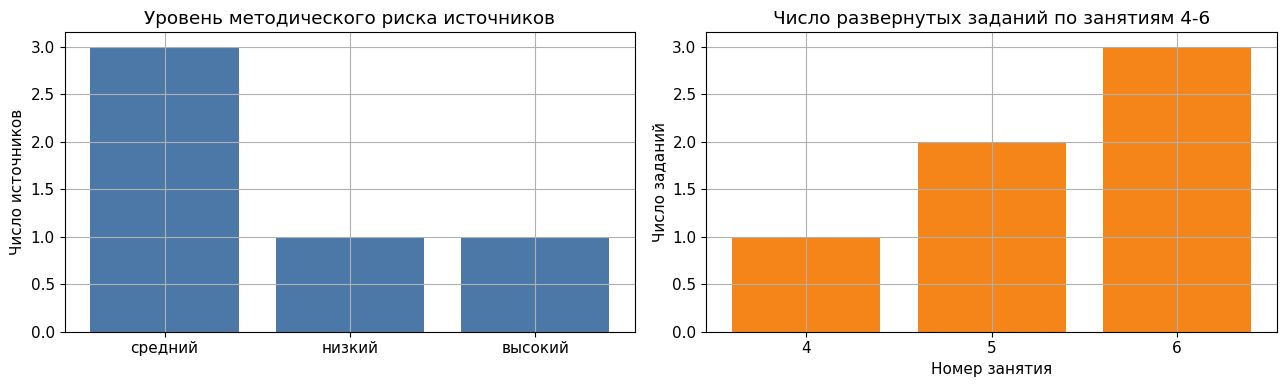

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

risk_counts = dataset_catalog_04_06["risk_level"].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color="#4c78a8")
axes[0].set_title("Уровень методического риска источников")
axes[0].set_ylabel("Число источников")

lesson_counts = (
    dataset_assignments_04_06["lesson"]
    .astype(str)
    .value_counts()
    .sort_index()
)
axes[1].bar(lesson_counts.index, lesson_counts.values, color="#f58518")
axes[1].set_title("Число развернутых заданий по занятиям 4-6")
axes[1].set_xlabel("Номер занятия")
axes[1].set_ylabel("Число заданий")

plt.tight_layout()
plt.show()

In [22]:
lesson_assignments = dataset_assignments_04_06[
    dataset_assignments_04_06["lesson"].astype(str) == "6"
].copy()

display(
    lesson_assignments[
        [
            "assignment_id",
            "assignment_title",
            "implementation_status",
            "dataset_structure",
            "theory_block",
            "practice_block",
            "recommended_visualizations",
            "expected_artifacts",
            "control_questions",
            "risk_note",
        ]
    ]
)

,assignment_id,assignment_title,implementation_status,dataset_structure,theory_block,practice_block,recommended_visualizations,expected_artifacts,control_questions,risk_note
1,nasa_cmapss_lesson_6,Кластеризация режимов и отделение диагностической разметки: C-MAPSS Aircraft Engine Simulator Data,methodology_only,Объект: симулированные траектории деградации авиационного турбовентиляторного двигателя. Формат: текстовые таблицы в...,"Опишите постановку обучения без учителя: сенсорные признаки используются до обучения, а коды отказов и служебные мет...","Разделите столбцы на сенсорные, служебные и диагностические, предложите k-means/PCA или DBSCAN, сформулируйте правил...",тепловая карта корреляций; PCA-проекция; профиль кластеров; сопоставление с отказами после обучения,"Краткий паспорт источника, таблица ролей столбцов, перечень рисков утечки данных, 2-3 рекомендуемые визуализации и в...",Почему отказ нельзя использовать как признак? Как выбрать число кластеров? Что означает шум DBSCAN?,"нужно разделять train/test по двигателям, а не случайно по строкам; часть сенсоров анонимизирована"
4,uci_ai4i_2020_lesson_6,Кластеризация режимов и отделение диагностической разметки: AI4I 2020 Predictive Maintenance Dataset,methodology_only,"Объект: синтетические, но промышленно мотивированные режимы оборудования и отказы. Формат: CSV. Доступ: UCI Machine ...","Опишите постановку обучения без учителя: сенсорные признаки используются до обучения, а коды отказов и служебные мет...","Разделите столбцы на сенсорные, служебные и диагностические, предложите k-means/PCA или DBSCAN, сформулируйте правил...",тепловая карта корреляций; PCA-проекция; профиль кластеров; сопоставление с отказами после обучения,"Краткий паспорт источника, таблица ролей столбцов, перечень рисков утечки данных, 2-3 рекомендуемые визуализации и в...",Почему отказ нельзя использовать как признак? Как выбрать число кластеров? Что означает шум DBSCAN?,столбцы отказов нельзя включать в признаки кластеризации; `Product ID` является служебным кодом
5,nasa_pcoe_adapt_lesson_6,Кластеризация режимов и отделение диагностической разметки: NASA PCoE ADAPT Diagnostic Data,methodology_only,Объект: диагностические данные испытательного стенда электропитания ADAPT. Формат: таблицы временных рядов и журналы...,"Опишите постановку обучения без учителя: сенсорные признаки используются до обучения, а коды отказов и служебные мет...","Разделите столбцы на сенсорные, служебные и диагностические, предложите k-means/PCA или DBSCAN, сформулируйте правил...",тепловая карта корреляций; PCA-проекция; профиль кластеров; сопоставление с отказами после обучения,"Краткий паспорт источника, таблица ролей столбцов, перечень рисков утечки данных, 2-3 рекомендуемые визуализации и в...",Почему отказ нельзя использовать как признак? Как выбрать число кластеров? Что означает шум DBSCAN?,сложная структура файлов; требуется предварительная нормализация временных шкал и событий


## Индивидуальное расширенное задание

Выберите один источник из таблицы выше и заполните в отчете
отдельный подраздел:

1. объект исследования и единица наблюдения;
2. какие столбцы являются измеряемыми признаками;
3. какая величина является целевой переменной или скрытой
   диагностической разметкой;
4. какие столбцы нельзя использовать как признаки из-за риска
   утечки данных;
5. какой способ разбиения выборки является корректным;
6. какие 2-3 графика нужно построить в первую очередь.

Если полный архив не скачивался, это нужно явно указать. В таком
случае результатом считается методически корректная постановка
расширенного задания, а не численное обучение модели.

## Мини-задание по открытому источнику

UCI `AI4I 2020 Predictive Maintenance Dataset` содержит
сенсорные признаки, служебные коды изделия и признаки отказов.
Для расширения работы укажите:

1. какие столбцы можно считать сенсорными признаками;
2. какие столбцы являются служебными идентификаторами;
3. какие столбцы являются диагностической разметкой и не должны
   использоваться до кластеризации;
4. какие графики следует построить для первичной интерпретации
   кластеров;
5. как использовать признаки отказов только после обучения
   алгоритма кластеризации.

## Задание для отчета

1. Объясните, чем кластеризация отличается от классификации.
2. Обоснуйте выбранное число кластеров по графикам `inertia` и
   силуэтного коэффициента.
3. Сравните k-means, DBSCAN и Gaussian Mixture.
4. Дайте инженерное описание 2-3 найденных кластеров.
5. Объясните, почему diagnostics-CSV нельзя использовать до
   завершения кластеризации.

Открытые источники для расширения: UCI AI4I 2020 Predictive
Maintenance Dataset и NASA C-MAPSS. Для открытых источников
необходимо отдельно фиксировать, какие столбцы являются
признаками, какие - отказами, а какие - служебной диагностической
разметкой.